# 12 — Vasicek/IRB em uma carteira PF brasileira

Este estudo reutiliza **a mesma geração sintética, os mesmos parâmetros e a mesma
semente do notebook 11** para aplicar o modelo gaussiano de um fator de Vasicek e
sua especialização regulatória IRB de varejo. O objetivo é calcular, em cada um dos
24 fechamentos reportados, perda esperada (EL), perda condicional adversa, capital
inesperado, RWA e a contribuição marginal de cada contrato.

O texto mantém separados quatro conceitos que frequentemente são confundidos:

1. **cenário macroeconômico**: um valor do fator sistemático $W$;
2. **perda condicional**: a perda média se aquele cenário ocorrer;
3. **capital ASRF/IRB**: perda condicional no percentil de 99,9% menos EL;
4. **RWA regulatório**: $12{,}5$ vezes o capital IRB.

A implementação segue o art. 46 da
[Resolução BCB 303](https://www.bcb.gov.br/estabilidadefinanceira/exibenormativo?numero=303&tipo=Resolu%C3%A7%C3%A3o+BCB),
as funções de varejo do [Basel Framework CRE31](https://www.bis.org/basel_framework/chapter/CRE/31.htm)
e a derivação ASRF da
[nota explicativa do BCBS](https://www.bis.org/bcbs/irbriskweight.pdf).
Os critérios para rotativo de varejo qualificado (QRRE) estão no
[CRE30](https://www.bis.org/basel_framework/chapter/CRE/30.htm).

> **Escopo e cautela regulatória.** Os dados são sintéticos. A PD do notebook 11
> não é uma estimativa aprovada de longo prazo, a EAD de cartão não inclui uma
> modelagem validada de conversão de limites não sacados e a hipótese de LGD não
> foi estimada com dados de recuperação. Portanto, o valor calculado é um estudo
> metodológico fiel à fórmula — não uma apuração oficial. O uso de IRB depende de
> autorização do Banco Central e de requisitos de dados, governança e validação.

## 1. Ambiente reprodutível e convenções

A primeira célula carrega bibliotecas numéricas, visualização, o simulador do
notebook 11 e o novo núcleo `vasicek_irb`. Usaremos a distribuição normal padrão
$Phi$ e sua inversa $Phi^{-1}$, implementadas por rotinas estáveis do SciPy.

A convenção de sinal será mantida em todo o estudo: **$W<0$ é economia adversa**.
Isso é importante porque alguns sistemas internos chamam de $W_i$ um multiplicador
crescente de estresse; a fórmula pode parecer diferente apenas por adotar o sinal
oposto. Espera-se ao final desta célula um ambiente determinístico e tabelas com
formatação consistente, sem qualquer cálculo de risco ainda.

In [1]:
# Imports e configuração visual compartilhada por todo o estudo.
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from scipy.special import ndtr, ndtri

from creditriskplus.retail import (
    BASE_PD_12M,
    RetailSimulationConfig,
    simulate_retail_portfolio,
)
from creditriskplus.vasicek_irb import (
    calculate_vasicek_irb,
    conditional_default_probability,
    conditional_portfolio_loss,
    retail_asset_correlation,
)

sns.set_theme(style='whitegrid', context='notebook')
COLORS = {'Cartão de crédito': '#1f77b4', 'Crédito pessoal parcelado': '#ff7f0e'}
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', lambda value: f'{value:,.4f}')
CONFIDENCE = 0.999
ADVERSE_W = float(ndtri(1.0 - CONFIDENCE))

print(f'Confiança IRB: {CONFIDENCE:.1%}')
print(f'Cenário sistemático equivalente: W = Φ⁻¹(1-q) = {ADVERSE_W:.6f}')

Confiança IRB: 99.9%
Cenário sistemático equivalente: W = Φ⁻¹(1-q) = -3.090232


## 2. A mesma carteira longitudinal do notebook 11

Repetimos literalmente a configuração do estudo anterior: backbook de 180 meses,
12 meses de burn-in, 24 fechamentos reportados, 60 MOBs de performance, os mesmos
volumes, choque e semente. O gerador representa contratos homogêneos por *pools*;
`obligor_count` é a multiplicidade exata do pool, e não um peso amostral.

Apenas os 24 meses a partir de janeiro de 2023 entram no cálculo IRB temporal. Os
meses posteriores existem no painel para maturar as curvas de safra do notebook 11,
mas não são novos fechamentos de capital. Esperamos recuperar 24 datas e os dois
produtos, confirmando que não foi criada uma segunda carteira.

In [2]:
# Configuração idêntica à célula de geração do notebook 11.
config = RetailSimulationConfig(
    reporting_start='2023-01-01',
    reporting_months=24,
    vintage_performance_months=60,
    backbook_months=180,
    burn_in_months=12,
    annual_origination_growth=0.05,
    shock_start_month=6,
    seed=20260808,
    unit_size=250.0,
)
panel = simulate_retail_portfolio(config)
reporting_months = pd.date_range(
    config.reporting_start, periods=config.reporting_months, freq='MS'
)
report_panel = panel[panel.observation_month.isin(reporting_months)].copy()

assert report_panel.observation_month.nunique() == 24
assert set(report_panel['product']) == set(COLORS)
assert (report_panel.obligor_count > 0).all()

portfolio_origin = pd.DataFrame({
    'métrica': ['linhas pool-mês', 'fechamentos', 'primeiro fechamento',
                'último fechamento', 'produtos'],
    'valor': [f'{len(report_panel):,}', report_panel.observation_month.nunique(),
              f'{reporting_months.min():%m/%Y}', f'{reporting_months.max():%m/%Y}',
              report_panel['product'].nunique()],
})
display(portfolio_origin)

,métrica,valor
0,linhas pool-mês,"18,771"
1,fechamentos,24
2,primeiro fechamento,01/2023
3,último fechamento,12/2024
4,produtos,2


## 3. PD, EAD, LGD e enquadramento regulatório

A fórmula IRB exige parâmetros com interpretações específicas:

- **PD**: média de longo prazo da taxa anual de default do grupo homogêneo;
- **EAD**: exposição esperada no momento do default;
- **LGD**: perda econômica percentual, incorporando condições adversas;
- **$R$**: correlação de ativos prescrita para a subcategoria de varejo.

A `pd_12m` do gerador contém o multiplicador macro corrente e, portanto, é
*point-in-time*. Para não passar uma PD cíclica como se fosse a PD de longo prazo,
reconstruímos exatamente a curva neutra do próprio processo gerador:

$$PD^{TTC}_{i}=\min(PD^{base}_{produto,faixa}\;s_{produto}(MOB),45\%).$$

Aplicamos pisos prudenciais de 0,10% ao cartão assumido QRRE e 0,05% aos demais,
além de LGD mínima de 50% e 30%, respectivamente. As LGDs sintéticas — 85% e 78%
— já excedem esses pisos. Cartão é marcado QRRE **como hipótese do cenário**;
produto rotativo, por si só, não prova baixa volatilidade de perdas nem todos os
demais critérios regulatórios. O parcelado é “demais varejo”. Espera-se que a
tabela evidencie os parâmetros usados e qualquer efeito dos pisos.

In [3]:
# Curvas de seasoning idênticas às usadas pelo gerador do notebook 11.
def neutral_seasoning(mob, product):
    mob = np.asarray(mob, dtype=float)
    if product == 'Cartão de crédito':
        return 0.65 + 0.70 * (1.0 - np.exp(-mob / 6.0))
    return 0.55 + 0.75 * (1.0 - np.exp(-mob / 5.0))


prepared = report_panel.reset_index(drop=True).copy()
prepared['risk_index'] = prepared['risk_band'].map({'A': 0, 'B': 1, 'C': 2, 'D': 3})
prepared['pd_long_run_raw'] = [
    min(
        BASE_PD_12M[product][risk_index] * neutral_seasoning(mob, product),
        0.45,
    )
    for product, risk_index, mob in zip(
        prepared['product'], prepared['risk_index'], prepared['mob']
    )
]
prepared['subcategory'] = np.where(
    prepared['product'].eq('Cartão de crédito'), 'qrre', 'other_retail'
)
prepared['pd_floor'] = np.where(prepared.subcategory.eq('qrre'), 0.0010, 0.0005)
prepared['lgd_raw'] = 1.0 - prepared['recovery_rate']
prepared['lgd_floor'] = np.where(prepared.subcategory.eq('qrre'), 0.50, 0.30)
prepared['pd_irb'] = np.maximum(prepared['pd_long_run_raw'], prepared['pd_floor'])
prepared['lgd_irb'] = np.maximum(prepared['lgd_raw'], prepared['lgd_floor'])
prepared['asset_correlation'] = retail_asset_correlation(
    prepared['pd_irb'], prepared['subcategory']
)
prepared['ead_total'] = prepared['ead_per_obligor'] * prepared['obligor_count']

# Médias ponderadas por EAD são mais informativas para capital que médias de pools.
def ead_weighted(group, column):
    return np.average(group[column], weights=group['ead_total'])

parameter_summary = prepared.groupby('product').apply(
    lambda group: pd.Series({
        'EAD média mensal (R$)': group.ead_total.sum() / 24,
        'PD TTC ponderada': ead_weighted(group, 'pd_irb'),
        'PD PIT ponderada': ead_weighted(group, 'pd_12m'),
        'LGD ponderada': ead_weighted(group, 'lgd_irb'),
        'R ponderada': ead_weighted(group, 'asset_correlation'),
        'linhas afetadas por piso PD': int((group.pd_irb > group.pd_long_run_raw).sum()),
        'linhas afetadas por piso LGD': int((group.lgd_irb > group.lgd_raw).sum()),
    }),
    include_groups=False,
)
display(parameter_summary)

,EAD média mensal (R$),PD TTC ponderada,PD PIT ponderada,LGD ponderada,R ponderada,linhas afetadas por piso PD,linhas afetadas por piso LGD
product,,,,,,,
Cartão de crédito,"34,455,815.6778",0.0541,0.0594,0.8500,0.0400,0.0000,0.0000
Crédito pessoal parcelado,"12,990,937.5000",0.0708,0.0774,0.7800,0.0593,0.0000,0.0000


## 4. Correlação de ativos: o elo entre PD e sensibilidade macro

A Resolução BCB 303 fixa $R=4\%$ para QRRE. Para demais exposições de varejo,

$$
R(PD)=0{,}03\frac{1-e^{-35PD}}{1-e^{-35}}
+0{,}16\left(1-\frac{1-e^{-35PD}}{1-e^{-35}}\right).
$$

Quando PD tende a zero, $R$ tende a 16%; quando PD cresce, $R$ converge para 3%.
A interpretação é que nomes de baixo risco na categoria “demais varejo” carregam
maior fração sistemática. O gráfico deve mostrar a linha QRRE horizontal e a curva
de demais varejo decrescente, além das PDs efetivamente observadas na carteira.

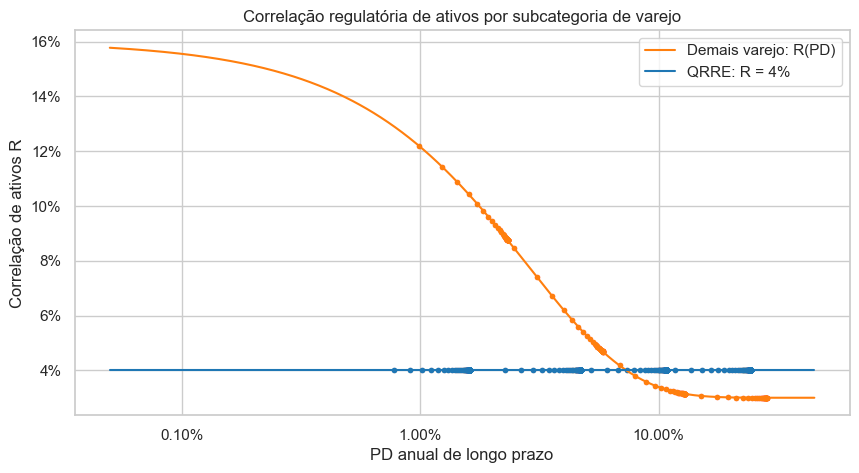

In [4]:
# Visualização da função regulatória de correlação.
pd_grid = np.geomspace(0.0005, 0.45, 500)
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(pd_grid, retail_asset_correlation(pd_grid, 'other_retail'),
        label='Demais varejo: R(PD)', color=COLORS['Crédito pessoal parcelado'])
ax.plot(pd_grid, retail_asset_correlation(pd_grid, 'qrre'),
        label='QRRE: R = 4%', color=COLORS['Cartão de crédito'])
for product, color in COLORS.items():
    points = prepared.loc[prepared['product'].eq(product), ['pd_irb', 'asset_correlation']]
    ax.scatter(points.pd_irb, points.asset_correlation, s=8, alpha=0.10, color=color)
ax.set_xscale('log')
ax.set_xlabel('PD anual de longo prazo')
ax.set_ylabel('Correlação de ativos R')
ax.set_title('Correlação regulatória de ativos por subcategoria de varejo')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.2%}')
ax.legend()
plt.show()

## 5. O modelo latente de Vasicek e a função de PD condicional

Para cada contrato $i$, o retorno latente de ativos é

$$A_i=\sqrt{R_i}\,W+\sqrt{1-R_i}\,\varepsilon_i,$$

em que $W$ é o fator comum e $\varepsilon_i$ é o fator idiossincrático; ambos são
normais-padrão independentes. Define-se default quando
$A_i\leq\Phi^{-1}(PD_i)$. Condicionando em $W=w$ e isolando $\varepsilon_i$:

$$p_i(w)=P(D_i\mid W=w)=
\Phi\!\left(\frac{\Phi^{-1}(PD_i)-\sqrt{R_i}w}{\sqrt{1-R_i}}\right).$$

O gráfico usa quatro contratos representativos. Todas as curvas devem cair quando
$W$ melhora. A faixa esquerda marca o cenário de cauda até $W=-3{,}09$, usado no
percentil de perda de 99,9%. A diferença de inclinação vem de PD e $R$, não de um
multiplicador macro arbitrário.

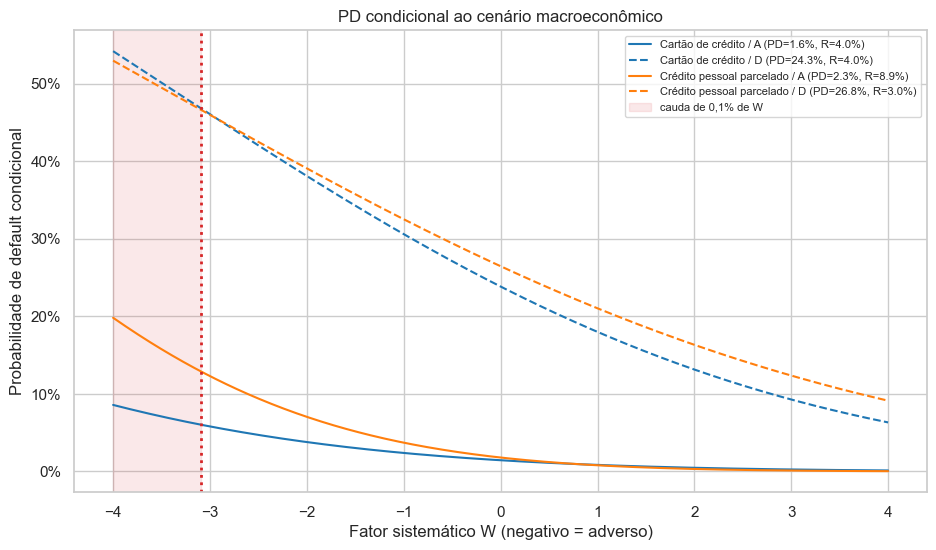

In [5]:
# Usa parâmetros medianos de cada combinação para evitar escolher um outlier.
representatives = prepared.groupby(['product', 'risk_band'], as_index=False).agg(
    pd_irb=('pd_irb', 'median'),
    asset_correlation=('asset_correlation', 'median'),
)
representatives = representatives[
    representatives.set_index(['product', 'risk_band']).index.isin([
        ('Cartão de crédito', 'A'), ('Cartão de crédito', 'D'),
        ('Crédito pessoal parcelado', 'A'), ('Crédito pessoal parcelado', 'D'),
    ])
]

w_grid = np.linspace(-4.0, 4.0, 500)
fig, ax = plt.subplots(figsize=(11, 6))
for row in representatives.itertuples():
    conditional = conditional_default_probability(
        np.full_like(w_grid, row.pd_irb),
        np.full_like(w_grid, row.asset_correlation),
        w_grid,
    )
    ax.plot(w_grid, conditional,
            label=f'{row.product} / {row.risk_band} (PD={row.pd_irb:.1%}, R={row.asset_correlation:.1%})',
            color=COLORS[row.product], linestyle='-' if row.risk_band == 'A' else '--')
ax.axvspan(-4.0, ADVERSE_W, color='#d62728', alpha=0.10, label='cauda de 0,1% de W')
ax.axvline(ADVERSE_W, color='#d62728', linestyle=':', linewidth=2)
ax.set(xlabel='Fator sistemático W (negativo = adverso)',
       ylabel='Probabilidade de default condicional',
       title='PD condicional ao cenário macroeconômico')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend(fontsize=8)
plt.show()

## 6. Prova numérica da consistência da PD

A PD de entrada é incondicional. Pela lei da esperança iterada,

$$P(D_i)=E_W[P(D_i\mid W)]=\int_{-\infty}^{\infty}p_i(w)\phi(w)\,dw.$$

A célula integra essa expressão com quadratura de Gauss–Hermite de 80 nós. Fazendo
$w=\sqrt{2}x$, a integral normal vira

$$E[p_i(W)]\approx\frac{1}{\sqrt{\pi}}\sum_j a_j p_i(\sqrt{2}x_j).$$

Essa não é uma calibração: é um teste de identidade matemática e de convenção de
sinal. O erro deve ficar próximo da precisão de ponto flutuante. Se a fórmula
tivesse $+\sqrt R w$ com a convenção atual, as curvas mudariam de direção, embora
a integral ainda coincidisse; por isso o teste anterior de monotonicidade também é
conceitualmente necessário.

In [6]:
# Validação E[P(D|W)] = PD em todas as combinações únicas da carteira.
nodes, weights = np.polynomial.hermite.hermgauss(80)
factors = np.sqrt(2.0) * nodes
unique_parameters = prepared[['pd_irb', 'asset_correlation']].drop_duplicates()
integration_rows = []
for row in unique_parameters.itertuples(index=False):
    conditional = conditional_default_probability(
        np.full_like(factors, row.pd_irb),
        np.full_like(factors, row.asset_correlation),
        factors,
    )
    integrated_pd = np.dot(weights, conditional) / np.sqrt(np.pi)
    integration_rows.append((row.pd_irb, integrated_pd, integrated_pd - row.pd_irb))
integration_check = pd.DataFrame(
    integration_rows, columns=['PD informada', 'PD integrada', 'erro absoluto']
)
assert integration_check['erro absoluto'].abs().max() < 2e-11
display(integration_check.iloc[[0, len(integration_check)//2, -1]])
print(f"Erro absoluto máximo: {integration_check['erro absoluto'].abs().max():.3e}")

,PD informada,PD integrada,erro absoluto
0,0.0152,0.0152,-0.0000
450,0.1080,0.1080,0.0000
900,0.1080,0.1080,-0.0000


Erro absoluto máximo: 1.388e-16


## 7. Do cenário adverso à fórmula de capital IRB

A perda condicional assintótica é

$$L(w)=\sum_i EAD_i\,LGD_i\,p_i(w).$$

Como $L(w)$ é decrescente, o quantil $q$ da perda ocorre em
$w_q=\Phi^{-1}(1-q)=-\Phi^{-1}(q)$. Substituindo esse valor em $p_i(w)$:

$$p_i^{downturn}=\Phi\!\left(
\frac{\Phi^{-1}(PD_i)+\sqrt{R_i}\Phi^{-1}(q)}{\sqrt{1-R_i}}
\right).$$

Para exposições de varejo performando, sem ajuste de maturidade:

$$K_i=LGD_i(p_i^{downturn}-PD_i),\qquad
Capital_i=EAD_iK_i,\qquad RWA_i=12{,}5\,Capital_i.$$

A função abaixo aplica essas identidades a cada pool, preserva os valores por
contrato e multiplica apenas no final por `obligor_count`. Espera-se reconciliação
exata entre perda adversa, EL e capital.

In [7]:
# Encapsula o cálculo de um fechamento sem esconder os vetores contratuais.
def evaluate_snapshot(snapshot, pd_column='pd_irb', card_as_other_retail=False):
    detail = snapshot.reset_index(drop=True).copy()
    categories = detail['subcategory'].to_numpy(copy=True)
    if card_as_other_retail:
        categories = np.where(detail['product'].eq('Cartão de crédito'),
                              'other_retail', categories)
    correlations = retail_asset_correlation(detail[pd_column], categories)
    result = calculate_vasicek_irb(
        pd=detail[pd_column],
        ead_per_obligor=detail['ead_per_obligor'],
        lgd=detail['lgd_irb'],
        asset_correlation=correlations,
        obligor_count=detail['obligor_count'],
        confidence=CONFIDENCE,
    )
    detail['pd_model'] = result.pd
    detail['asset_correlation_model'] = result.asset_correlation
    detail['downturn_pd'] = result.downturn_pd
    detail['expected_loss_per_contract'] = result.expected_loss_per_obligor
    detail['adverse_loss_per_contract'] = result.adverse_loss_per_obligor
    detail['marginal_capital_per_ead'] = result.marginal_capital_per_ead
    detail['capital_per_contract'] = result.capital_per_obligor
    detail['expected_loss_pool'] = result.expected_loss_pool
    detail['adverse_loss_pool'] = result.adverse_loss_pool
    detail['capital_pool'] = result.capital_pool
    detail['rwa_pool'] = result.rwa_pool
    totals = {
        'ead': result.total_ead,
        'expected_loss': result.total_expected_loss,
        'adverse_loss_999': result.total_adverse_loss,
        'capital_999': result.total_capital,
        'rwa': result.total_rwa,
    }
    assert np.isclose(totals['capital_999'],
                      totals['adverse_loss_999'] - totals['expected_loss'])
    return detail, totals

demonstration_month = reporting_months[0]
demonstration_detail, demonstration_totals = evaluate_snapshot(
    prepared[prepared.observation_month.eq(demonstration_month)]
)
display(pd.Series(demonstration_totals, name=f'{demonstration_month:%m/%Y}').to_frame())

,01/2023
ead,"47,830,773.6278"
expected_loss,"2,349,379.1476"
adverse_loss_999,"6,313,209.6432"
capital_999,"3,963,830.4957"
rwa,"49,547,881.1958"


## 8. Capital em cada um dos 24 fechamentos

Calcularemos duas séries com a mesma EAD e LGD:

- **IRB/TTC (principal):** usa a PD neutra de longo prazo reconstruída;
- **PIT (diagnóstico):** insere a PD macro corrente na mesma fórmula.

A segunda série não é rotulada capital regulatório: ela mostra o erro conceitual de
misturar uma PD cíclica com a função concebida para PD de longo prazo. Para cada
mês, guardamos também as contribuições por pool. O capital total deve ser a soma
exata das contribuições, o RWA deve ser $12{,}5$ vezes o capital, e a tabela deve
conter exatamente 24 linhas.

In [8]:
# Executa a mesma função vetorial em todos os fechamentos reportados.
timeline_rows = []
detailed_months = []
for month in reporting_months:
    snapshot = prepared[prepared.observation_month.eq(month)].copy()
    detail_ttc, totals_ttc = evaluate_snapshot(snapshot, 'pd_irb')

    # A PD PIT também respeita o piso; ela é apenas uma análise de sensibilidade.
    snapshot['pd_pit_floored'] = np.maximum(snapshot['pd_12m'], snapshot['pd_floor'])
    _, totals_pit = evaluate_snapshot(snapshot, 'pd_pit_floored')
    detail_ttc['observation_month'] = month
    detailed_months.append(detail_ttc)
    timeline_rows.append({
        'observation_month': month,
        **totals_ttc,
        'capital_pit_diagnostic': totals_pit['capital_999'],
    })

timeline = pd.DataFrame(timeline_rows)
details_over_time = pd.concat(detailed_months, ignore_index=True)
timeline['el_rate'] = timeline['expected_loss'] / timeline['ead']
timeline['capital_rate'] = timeline['capital_999'] / timeline['ead']
timeline['rwa_density'] = timeline['rwa'] / timeline['ead']

assert len(timeline) == 24
assert np.allclose(timeline['rwa'], 12.5 * timeline['capital_999'])
assert np.isclose(details_over_time.capital_pool.sum(), timeline.capital_999.sum())

display(timeline.head(4))

,observation_month,ead,expected_loss,adverse_loss_999,capital_999,rwa,capital_pit_diagnostic,el_rate,capital_rate,rwa_density
0,2023-01-01,"47,830,773.6278","2,349,379.1476","6,313,209.6432","3,963,830.4957","49,547,881.1958","3,963,830.4957",0.0491,0.0829,1.0359
1,2023-02-01,"47,812,434.9595","2,352,776.3527","6,316,195.7322","3,963,419.3794","49,542,742.2431","4,011,510.7341",0.0492,0.0829,1.0362
2,2023-03-01,"47,811,616.5126","2,352,718.8840","6,317,219.0226","3,964,500.1386","49,556,251.7323","4,047,331.6327",0.0492,0.0829,1.0365
3,2023-04-01,"47,738,245.5582","2,346,467.1695","6,300,854.7623","3,954,387.5928","49,429,844.9095","4,049,693.7275",0.0492,0.0828,1.0354


## 9. Evolução temporal: exposição, EL, capital e densidades

O capital em reais pode crescer por três motivos distintos: mais EAD, mudança de
mix para contratos arriscados ou alteração dos parâmetros. As taxas `EL/EAD` e
`Capital/EAD` retiram o efeito de escala e ajudam a separar essas causas.

Como a série principal usa PD TTC, o choque sintético não entra diretamente na PD;
ainda pode afetar EAD de cartão, originação e composição. A curva PIT deve reagir
mais fortemente ao choque, ilustrando por que capital regulatório e *stress testing*
não são a mesma métrica. Espera-se também `RWA/EAD = 12,5 × Capital/EAD`.

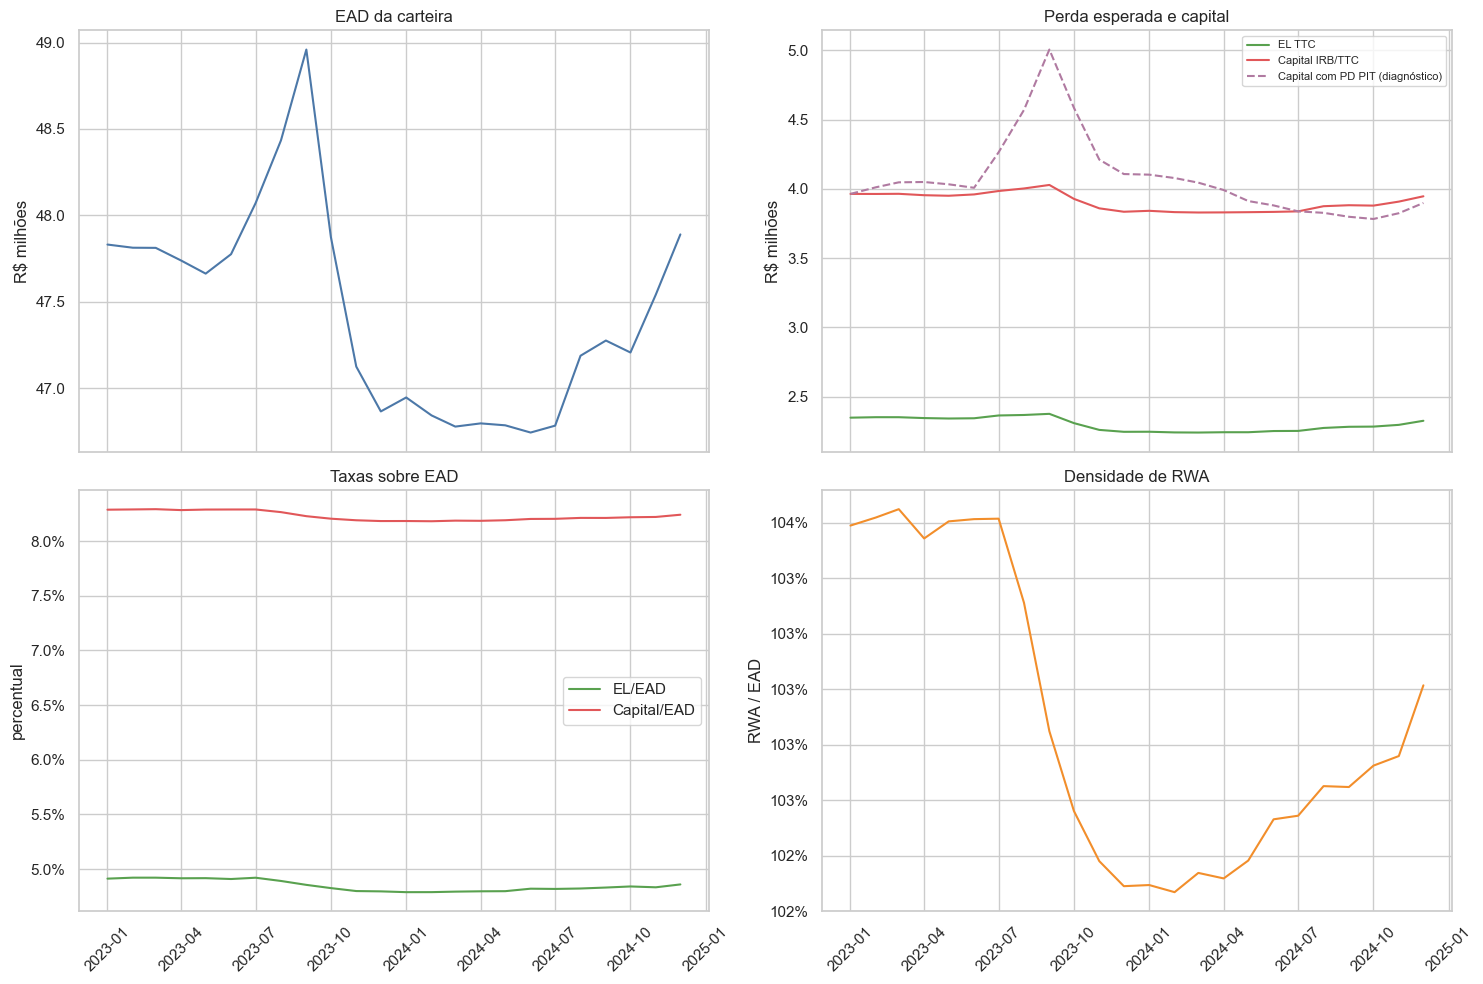

In [9]:
# Painel temporal com níveis e taxas para evitar interpretações por escala.
fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes[0, 0].plot(timeline.observation_month, timeline.ead / 1e6, color='#4c78a8')
axes[0, 0].set(title='EAD da carteira', ylabel='R$ milhões')

axes[0, 1].plot(timeline.observation_month, timeline.expected_loss / 1e6,
                label='EL TTC', color='#59a14f')
axes[0, 1].plot(timeline.observation_month, timeline.capital_999 / 1e6,
                label='Capital IRB/TTC', color='#e15759')
axes[0, 1].plot(timeline.observation_month, timeline.capital_pit_diagnostic / 1e6,
                label='Capital com PD PIT (diagnóstico)', color='#b07aa1', linestyle='--')
axes[0, 1].set(title='Perda esperada e capital', ylabel='R$ milhões')
axes[0, 1].legend(fontsize=8)

axes[1, 0].plot(timeline.observation_month, timeline.el_rate,
                label='EL/EAD', color='#59a14f')
axes[1, 0].plot(timeline.observation_month, timeline.capital_rate,
                label='Capital/EAD', color='#e15759')
axes[1, 0].set(title='Taxas sobre EAD', ylabel='percentual')
axes[1, 0].yaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
axes[1, 0].legend()

axes[1, 1].plot(timeline.observation_month, timeline.rwa_density,
                color='#f28e2b')
axes[1, 1].set(title='Densidade de RWA', ylabel='RWA / EAD')
axes[1, 1].yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
for ax in axes.flat:
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 10. Decomposição aditiva por produto e faixa de risco

No limite ASRF, cada linha contribui
$n_iEAD_iLGD_i(p_i^{downturn}-PD_i)$. Por isso podemos somar o capital por produto,
faixa, safra ou qualquer outra dimensão sem rateio residual. Essa propriedade é
mais forte que uma atribuição proporcional: cada parcela vem da própria derivada
da função de capital.

O primeiro gráfico deve reconciliar visualmente com a curva total; o segundo mostra
se o aumento temporal vem das faixas de maior risco. Como cartão e parcelado usam
funções de correlação diferentes, capital não deve ser inferido apenas comparando
suas PDs.

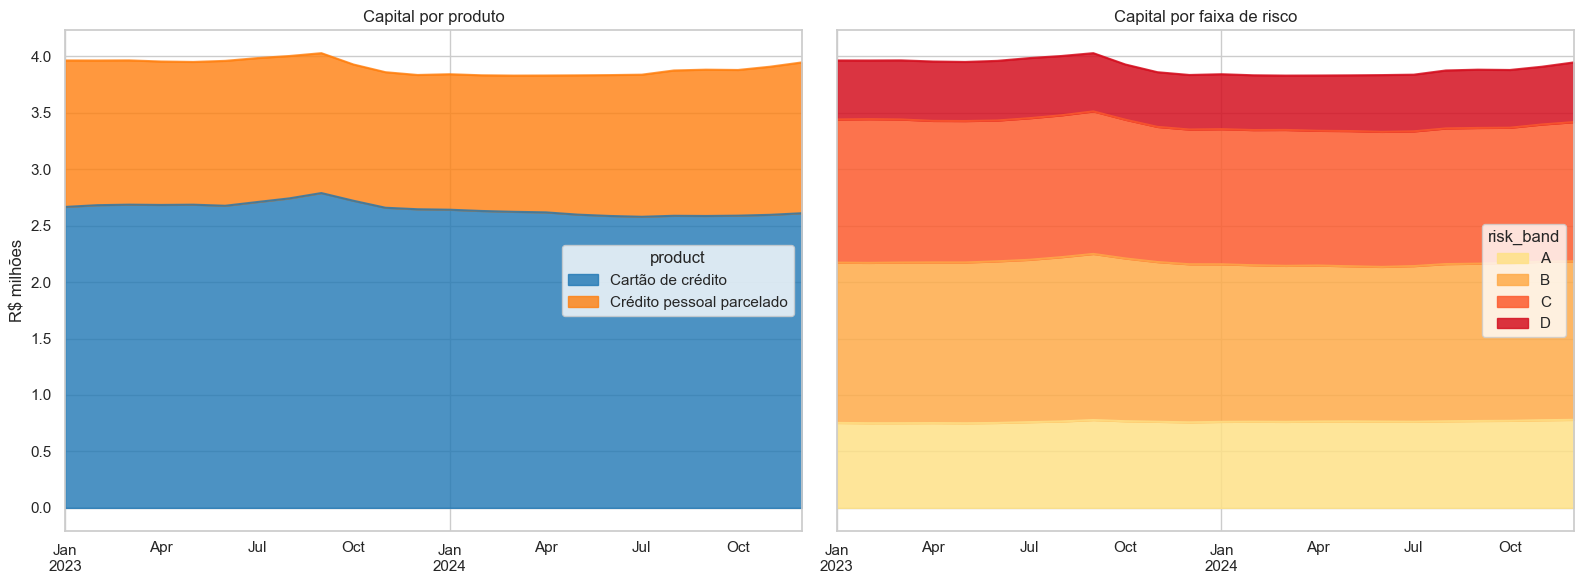

In [10]:
# Agregações preservam exatamente a soma das contribuições calculadas por pool.
by_product = details_over_time.groupby(
    ['observation_month', 'product'], as_index=False
)['capital_pool'].sum()
by_risk = details_over_time.groupby(
    ['observation_month', 'risk_band'], as_index=False
)['capital_pool'].sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
product_pivot = by_product.pivot(index='observation_month', columns='product',
                                 values='capital_pool') / 1e6
product_pivot.plot.area(ax=axes[0], color=[COLORS.get(c) for c in product_pivot.columns],
                        alpha=0.80)
axes[0].set(title='Capital por produto', xlabel='', ylabel='R$ milhões')

risk_pivot = by_risk.pivot(index='observation_month', columns='risk_band',
                           values='capital_pool') / 1e6
risk_pivot[['A', 'B', 'C', 'D']].plot.area(
    ax=axes[1], color=sns.color_palette('YlOrRd', 4), alpha=0.85
)
axes[1].set(title='Capital por faixa de risco', xlabel='')
plt.tight_layout()
plt.show()

reconciliation = product_pivot.sum(axis=1).to_numpy() * 1e6
assert np.allclose(reconciliation, timeline['capital_999'])

## 11. Escolha do fechamento crítico e reconciliação econômica

Para examinar contratos individualmente, selecionamos o mês com maior capital
IRB/TTC — critério objetivo, e não uma data escolhida depois de olhar as
contribuições. Nesse fechamento verificaremos:

$$Capital_{carteira}=L(w_{99,9\%})-EL=\sum_i Capital_i,$$

e apresentaremos EAD, EL, perda adversa, capital e RWA. A diferença entre perda
adversa e capital é a EL: capital inesperado não cobre duas vezes a perda média.
O capital aqui é para exposições performando; contratos já em default requerem o
tratamento regulatório específico e não existem como ativos no painel gerado.

In [11]:
# O pico temporal determina o snapshot usado nas análises contratuais seguintes.
peak_month = timeline.loc[timeline.capital_999.idxmax(), 'observation_month']
peak_detail = details_over_time[
    details_over_time.observation_month.eq(peak_month)
].reset_index(drop=True)

peak_metrics = pd.Series({
    'Mês selecionado': f'{peak_month:%m/%Y}',
    'Contratos ativos': int(peak_detail.obligor_count.sum()),
    'EAD': peak_detail.ead_total.sum(),
    'Perda esperada': peak_detail.expected_loss_pool.sum(),
    'Perda condicional em 99,9%': peak_detail.adverse_loss_pool.sum(),
    'Capital inesperado': peak_detail.capital_pool.sum(),
    'RWA': peak_detail.rwa_pool.sum(),
}, name='valor')
display(peak_metrics.to_frame())

assert np.isclose(
    peak_detail.capital_pool.sum(),
    peak_detail.adverse_loss_pool.sum() - peak_detail.expected_loss_pool.sum(),
)

,valor
Mês selecionado,09/2023
Contratos ativos,13929
EAD,"48,959,991.9009"
Perda esperada,"2,376,963.2800"
"Perda condicional em 99,9%","6,405,343.8282"
Capital inesperado,"4,028,380.5482"
RWA,"50,354,756.8521"


## 12. Contribuição marginal e Euler de cada contrato

Seja o capital da carteira, com parâmetros fixos,

$$C(\mathbf{EAD})=\sum_i EAD_iK_i.$$

A derivada em relação à exposição de um contrato é

$$\frac{\partial C}{\partial EAD_i}=K_i
=LGD_i(p_i^{downturn}-PD_i).$$

Pela homogeneidade de grau um, a contribuição Euler é

$$C_i=EAD_i\frac{\partial C}{\partial EAD_i}=EAD_iK_i,$$

e $\sum_i C_i=C$. A célula expande as multiplicidades dos pools apenas para criar
uma tabela com **uma linha por contrato ativo**. Contratos do mesmo pool são
indistinguíveis no gerador; os IDs são chaves sintéticas do fechamento, não uma
trajetória individual longitudinal. Esperamos reconciliação na precisão numérica.

In [12]:
# Expansão literal para materializar a contribuição de cada contrato no pico.
repeated_pool_rows = np.repeat(
    np.arange(len(peak_detail)), peak_detail['obligor_count'].to_numpy(dtype=int)
)
contracts = peak_detail.iloc[repeated_pool_rows].copy().reset_index(drop=True)
contracts['pool_row'] = repeated_pool_rows
contracts['contract_number_in_pool'] = contracts.groupby('pool_row').cumcount() + 1
contracts['contract_id'] = (
    peak_month.strftime('%Y%m') + '-P' + contracts['pool_row'].astype(str).str.zfill(4)
    + '-C' + contracts['contract_number_in_pool'].astype(str).str.zfill(4)
)
contracts['capital_contribution'] = contracts['capital_per_contract']
contracts['rwa_contribution'] = 12.5 * contracts['capital_contribution']

assert len(contracts) == peak_detail.obligor_count.sum()
assert np.isclose(contracts.capital_contribution.sum(), peak_detail.capital_pool.sum())
assert np.isclose(contracts.rwa_contribution.sum(), peak_detail.rwa_pool.sum())

display(contracts[[
    'contract_id', 'product', 'risk_band', 'mob', 'ead_per_obligor',
    'pd_model', 'lgd_irb', 'asset_correlation_model', 'downturn_pd',
    'marginal_capital_per_ead', 'capital_contribution', 'rwa_contribution',
]].head(10))
print(f'Tabela contratual materializada: {len(contracts):,} contratos.')

,contract_id,product,risk_band,mob,ead_per_obligor,pd_model,lgd_irb,asset_correlation_model,downturn_pd,marginal_capital_per_ead,capital_contribution,rwa_contribution
0,202309-P0000-C0001,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
1,202309-P0000-C0002,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
2,202309-P0000-C0003,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
3,202309-P0000-C0004,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
4,202309-P0000-C0005,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
5,202309-P0000-C0006,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
6,202309-P0000-C0007,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
7,202309-P0000-C0008,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
8,202309-P0000-C0009,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"
9,202309-P0000-C0010,Cartão de crédito,A,21,"2,535.1223",0.0159,0.8500,0.0400,0.0595,0.0370,93.7946,"1,172.4322"


Tabela contratual materializada: 13,929 contratos.


## 13. Leitura prática do capital marginal

`marginal_capital_per_ead` responde: “quanto capital adicional surge ao aumentar
em R$ 1 a EAD deste contrato, sem alterar PD, LGD, $R$ ou os demais contratos?”.
Já `capital_contribution` responde quanto do capital atual é atribuído ao contrato.

Para um **novo** contrato, essa derivada é válida se sua inclusão não mudar a
calibração dos pools nem a elegibilidade regulatória. Alterações de mix que levem a
recalibração de PD/LGD ou revelem concentração não estão contidas nessa derivada.
A tabela mostra os maiores valores absolutos; portanto tende a priorizar contratos
que combinam EAD alta, LGD alta e taxa marginal alta.

In [13]:
# Ranking contratual e estatísticas da taxa marginal, sem esconder empates de pool.
top_contracts = contracts.nlargest(15, 'capital_contribution')[[
    'contract_id', 'product', 'risk_band', 'mob', 'ead_per_obligor',
    'pd_model', 'downturn_pd', 'marginal_capital_per_ead',
    'capital_contribution', 'rwa_contribution',
]]
display(top_contracts)

marginal_summary = contracts.groupby(['product', 'risk_band']).agg(
    contratos=('contract_id', 'size'),
    EAD=('ead_per_obligor', 'sum'),
    taxa_marginal_media=('marginal_capital_per_ead', 'mean'),
    capital=('capital_contribution', 'sum'),
    capital_medio_contrato=('capital_contribution', 'mean'),
)
display(marginal_summary)

,contract_id,product,risk_band,mob,ead_per_obligor,pd_model,downturn_pd,marginal_capital_per_ead,capital_contribution,rwa_contribution
13433,202309-P0759-C0001,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13434,202309-P0759-C0002,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13435,202309-P0759-C0003,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13436,202309-P0759-C0004,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13437,202309-P0759-C0005,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13438,202309-P0759-C0006,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13439,202309-P0759-C0007,Crédito pessoal parcelado,D,2,"11,000.0000",0.1754,0.3441,0.1315,"1,447.0433","18,088.0407"
13210,202309-P0751-C0001,Crédito pessoal parcelado,D,3,"10,500.0000",0.1954,0.3720,0.1377,"1,446.2419","18,078.0241"
13211,202309-P0751-C0002,Crédito pessoal parcelado,D,3,"10,500.0000",0.1954,0.3720,0.1377,"1,446.2419","18,078.0241"
13212,202309-P0751-C0003,Crédito pessoal parcelado,D,3,"10,500.0000",0.1954,0.3720,0.1377,"1,446.2419","18,078.0241"


contratos             EAD  \
product                   risk_band                              
Cartão de crédito         A               5612 14,074,130.8393   
                          B               3806 13,090,016.6781   
                          C               1589  7,061,362.4146   
                          D                359  1,908,437.5245   
Crédito pessoal parcelado A                821  3,356,500.0000   
                          B                994  4,967,100.0000   
                          C                579  3,351,444.4444   
                          D                169  1,151,000.0000   

                                     taxa_marginal_media        capital  \
product                   risk_band                                       
Cartão de crédito         A                       0.0365   515,249.1516   
                          B                       0.0775 1,017,840.1661   
                          C                       0.1274   903,490.1872   
                          D                       0.1839   352,433.3522   
Crédito pessoal parcelado A                       0.0803   263,136.1072   
                          B                       0.0922   453,531.7452   
                          C                       0.1100   359,227.6413   
                          D                       0.1474   163,472.1973   

                                     capital_medio_contrato  
product                   risk_band                          
Cartão de crédito         A                         91.8120  
                          B                        267.4304  
                          C                        568.5904  
                          D                        981.7085  
Crédito pessoal parcelado A                        320.5068  
                          B                        456.2694  
                          C                        620.4277  
                          D                        967.2911

## 14. Onde o capital se concentra: produto × faixa de risco

Uma taxa de default alta não garante a maior contribuição total: a célula também
depende de EAD, LGD, correlação e quantidade de contratos. O mapa de calor agrega
contribuições contratuais, mantendo a identidade Euler. A tabela complementar
apresenta EAD, capital e capital/EAD.

Espera-se que faixas C/D tenham taxas unitárias altas, mas faixas A/B podem ainda
ser relevantes por volume. Esse contraste é essencial para decisões de carteira:
risco unitário e concentração monetária são dimensões diferentes.

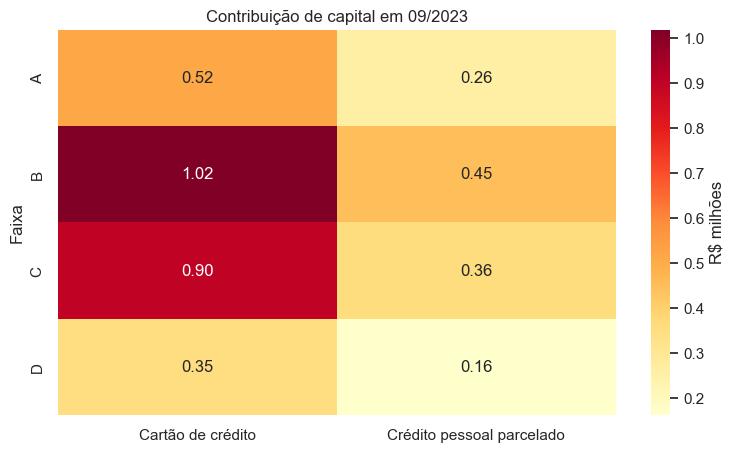

EAD           EL  \
product                   risk_band                                
Cartão de crédito         A         14,074,130.8393 188,331.4208   
                          B         13,090,016.6781 507,856.9025   
                          C          7,061,362.4146 613,480.0038   
                          D          1,908,437.5245 361,756.8362   
Crédito pessoal parcelado A          3,356,500.0000  49,859.3372   
                          B          4,967,100.0000 183,814.4629   
                          C          3,351,444.4444 275,093.1926   
                          D          1,151,000.0000 196,771.1241   

                                           Capital             RWA  \
product                   risk_band                                  
Cartão de crédito         A           515,249.1516  6,440,614.3953   
                          B         1,017,840.1661 12,723,002.0764   
                          C           903,490.1872 11,293,627.3401   
                          D           352,433.3522  4,405,416.9023   
Crédito pessoal parcelado A           263,136.1072  3,289,201.3398   
                          B           453,531.7452  5,669,146.8152   
                          C           359,227.6413  4,490,345.5165   
                          D           163,472.1973  2,043,402.4666   

                                     Capital/EAD  
product                   risk_band               
Cartão de crédito         A               0.0366  
                          B               0.0778  
                          C               0.1279  
                          D               0.1847  
Crédito pessoal parcelado A               0.0784  
                          B               0.0913  
                          C               0.1072  
                          D               0.1420

In [14]:
# Matriz de contribuição absoluta e relativa no fechamento de pico.
contribution_matrix = contracts.pivot_table(
    index='risk_band', columns='product', values='capital_contribution', aggfunc='sum'
).reindex(['A', 'B', 'C', 'D'])
segment_table = contracts.groupby(['product', 'risk_band']).agg(
    EAD=('ead_per_obligor', 'sum'),
    EL=('expected_loss_per_contract', 'sum'),
    Capital=('capital_contribution', 'sum'),
    RWA=('rwa_contribution', 'sum'),
)
segment_table['Capital/EAD'] = segment_table['Capital'] / segment_table['EAD']

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(contribution_matrix / 1e6, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'R$ milhões'})
ax.set(title=f'Contribuição de capital em {peak_month:%m/%Y}', xlabel='', ylabel='Faixa')
plt.show()
display(segment_table)

## 15. PD versus taxa marginal: uma relação não linear

A taxa $K_i$ não cresce linearmente com PD. Em demais varejo, a própria correlação
cai quando a PD cresce; além disso, o deslocamento por $\Phi^{-1}$ comprime as
extremidades. No QRRE, $R$ é constante, mas a curvatura normal permanece.

Cada ponto abaixo é um pool do fechamento crítico. O tamanho representa a raiz do
número de contratos apenas para legibilidade; a posição vertical é a derivada
correta por real de EAD. O gráfico deve revelar curvas distintas por produto e
evitar a falsa regra “dobrar PD dobra capital”.

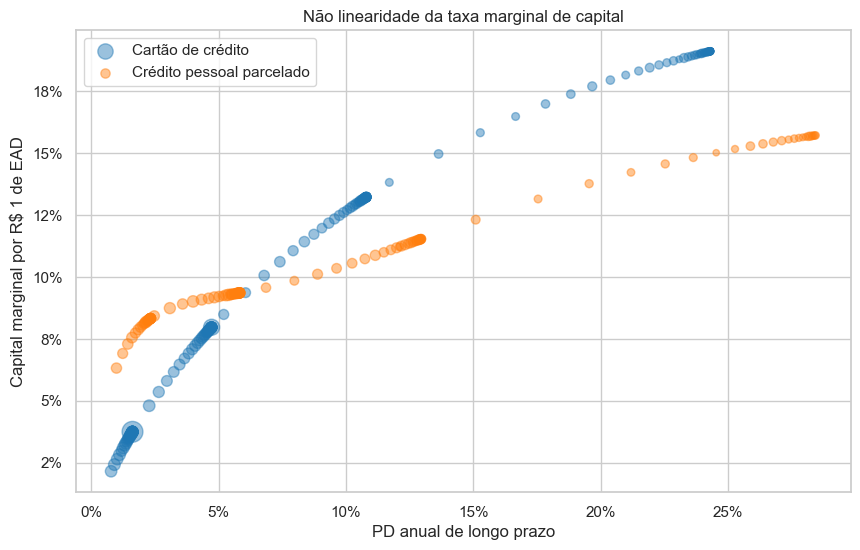

In [15]:
# Dispersão das taxas marginais por pool; transparência reduz sobreposição.
fig, ax = plt.subplots(figsize=(10, 6))
for product, group in peak_detail.groupby('product'):
    ax.scatter(group.pd_model, group.marginal_capital_per_ead,
               s=10 + 8 * np.sqrt(group.obligor_count), alpha=0.45,
               color=COLORS[product], label=product)
ax.set(xlabel='PD anual de longo prazo', ylabel='Capital marginal por R$ 1 de EAD',
       title='Não linearidade da taxa marginal de capital')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend()
plt.show()

## 16. Curva de concentração das contribuições

Ordenamos contratos do maior para o menor $C_i$ e calculamos a fração acumulada do
capital. Se todos contribuíssem igualmente, a curva seguiria a diagonal; quanto
mais acima dela, mais capital está concentrado em poucos contratos.

Essa é uma visualização de **contribuições ASRF**, não uma correção de concentração.
O modelo IRB pressupõe carteira infinitamente granular e não adiciona o risco
idiossincrático de grandes nomes ao capital. Portanto a curva diagnostica a
desigualdade das parcelas lineares, mas uma carteira concentrada exigiria ajuste de
granularidade ou simulação finita para medir VaR econômico com fidelidade.

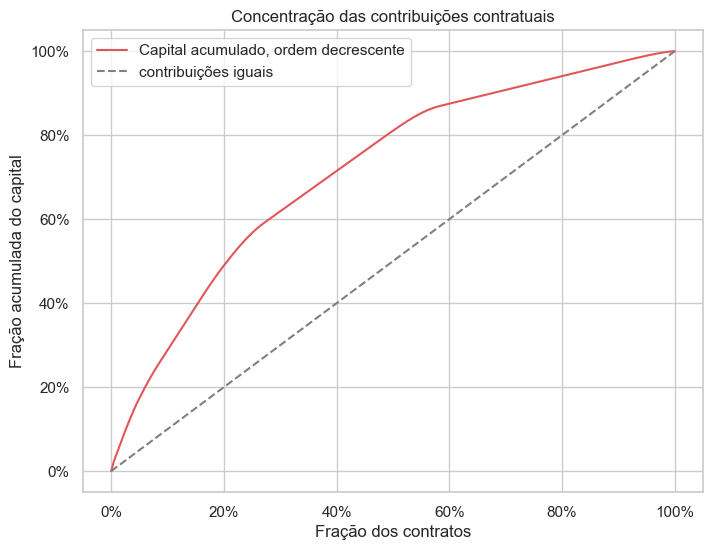

1% dos contratos concentra 4.25% do capital.
10% dos contratos concentra 28.81% do capital.


In [16]:
# Curva acumulada e indicadores de concentração das contribuições Euler.
ordered = contracts.sort_values('capital_contribution', ascending=False).copy()
ordered['fraction_contracts'] = np.arange(1, len(ordered) + 1) / len(ordered)
ordered['cumulative_capital'] = (
    ordered.capital_contribution.cumsum() / ordered.capital_contribution.sum()
)
share_top_1 = ordered.head(max(1, int(np.ceil(0.01 * len(ordered))))).capital_contribution.sum() / ordered.capital_contribution.sum()
share_top_10 = ordered.head(max(1, int(np.ceil(0.10 * len(ordered))))).capital_contribution.sum() / ordered.capital_contribution.sum()

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(ordered.fraction_contracts, ordered.cumulative_capital,
        color='#e15759', label='Capital acumulado, ordem decrescente')
ax.plot([0, 1], [0, 1], color='gray', linestyle='--', label='contribuições iguais')
ax.set(xlabel='Fração dos contratos', ylabel='Fração acumulada do capital',
       title='Concentração das contribuições contratuais')
ax.xaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
ax.legend()
plt.show()
print(f'1% dos contratos concentra {share_top_1:.2%} do capital.')
print(f'10% dos contratos concentra {share_top_10:.2%} do capital.')

## 17. O fator macro $W$: cenários e perda condicional

A função que pode ser lembrada como tendo um parâmetro $W_i$ é precisamente a PD
condicional. Com nossa convenção, $W=+2$ é favorável, $W=0$ é um cenário mediano,
$W=-2$ é recessivo e $W=-3{,}0902$ é o cenário associado ao VaR de 99,9%.

Importante: $L(0)$ geralmente **não** é igual à EL. A igualdade correta é
$E[L(W)]=EL$; não se deve substituir uma média sobre cenários pelo cenário médio do
fator em uma função não linear. O gráfico deve ser monotonicamente decrescente e o
ponto vermelho deve coincidir com a perda adversa usada no capital.

,cenário,W,percentil de W,perda condicional,perda / EAD
0,muito favorável,2.0000,0.9772,"1,005,332.1306",0.0205
1,favorável,1.0000,0.8413,"1,520,007.3706",0.0310
2,mediano,0.0000,0.5000,"2,243,903.6565",0.0458
3,adverso,-1.0000,0.1587,"3,233,830.1860",0.0661
4,muito adverso,-2.0000,0.0228,"4,547,395.3265",0.0929
5,"cauda IRB 99,9%",-3.0902,0.0010,"6,405,343.8282",0.1308


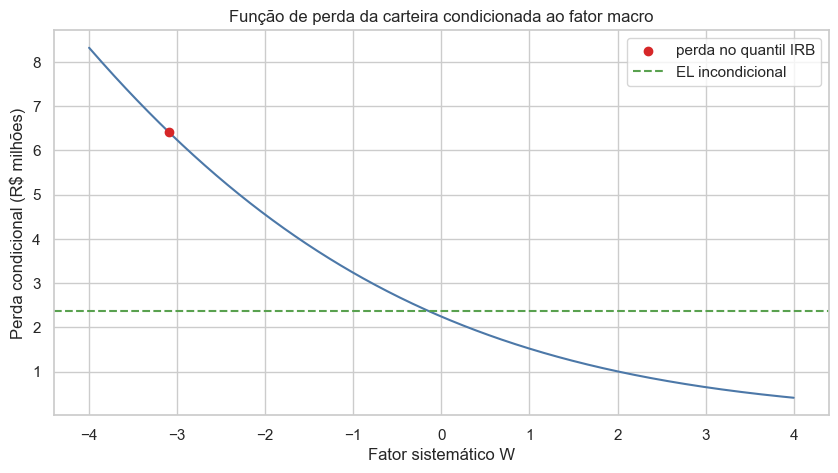

In [17]:
# Calcula a perda condicional em cenários nomeados e em uma grade contínua.
scenario_values = [2.0, 1.0, 0.0, -1.0, -2.0, ADVERSE_W]
scenario_names = ['muito favorável', 'favorável', 'mediano', 'adverso',
                  'muito adverso', 'cauda IRB 99,9%']
scenario_losses = [
    conditional_portfolio_loss(
        peak_detail.pd_model, peak_detail.ead_per_obligor, peak_detail.lgd_irb,
        peak_detail.asset_correlation_model, factor, peak_detail.obligor_count
    )
    for factor in scenario_values
]
scenario_table = pd.DataFrame({
    'cenário': scenario_names,
    'W': scenario_values,
    'percentil de W': ndtr(scenario_values),
    'perda condicional': scenario_losses,
    'perda / EAD': np.asarray(scenario_losses) / peak_detail.ead_total.sum(),
})
display(scenario_table)

loss_w = np.array([
    conditional_portfolio_loss(
        peak_detail.pd_model, peak_detail.ead_per_obligor, peak_detail.lgd_irb,
        peak_detail.asset_correlation_model, factor, peak_detail.obligor_count
    )
    for factor in w_grid
])
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(w_grid, loss_w / 1e6, color='#4c78a8')
ax.scatter([ADVERSE_W], [peak_detail.adverse_loss_pool.sum() / 1e6],
           color='#d62728', zorder=3, label='perda no quantil IRB')
ax.axhline(peak_detail.expected_loss_pool.sum() / 1e6, color='#59a14f',
           linestyle='--', label='EL incondicional')
ax.set(xlabel='Fator sistemático W', ylabel='Perda condicional (R$ milhões)',
       title='Função de perda da carteira condicionada ao fator macro')
ax.legend()
plt.show()

## 18. Sensibilidade à classificação do cartão

QRRE exige simultaneamente caráter rotativo, ausência de garantia, exposição a
pessoa natural, limite agregado, baixa volatilidade relativa de perdas e critérios
de gestão/supervisão. Os dados sintéticos não demonstram todos esses requisitos.

Por isso confrontamos a hipótese principal ($R=4\%$) com a reclassificação de todo
cartão como “demais varejo”, cuja correlação é maior nas PDs baixas. Essa não é uma
escolha livre para reduzir capital: a classificação deve ser comprovada. Espera-se
capital maior no cenário conservador, quantificando a materialidade da hipótese em
vez de escondê-la.

,hipótese,capital,RWA,variação de capital
0,Cartão elegível a QRRE,"4,028,380.5482","50,354,756.8521",0.0000
1,Todo cartão em demais varejo,"4,804,524.1725","60,056,552.1567",0.1927


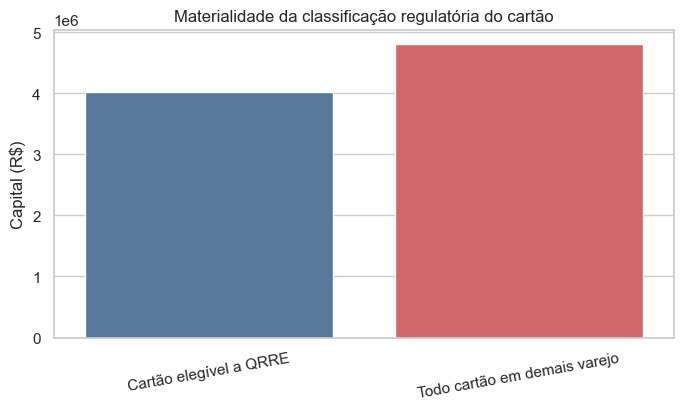

In [18]:
# Recalcula o mesmo fechamento alterando somente a função R aplicada ao cartão.
_, peak_base = evaluate_snapshot(
    prepared[prepared.observation_month.eq(peak_month)], 'pd_irb'
)
_, peak_conservative = evaluate_snapshot(
    prepared[prepared.observation_month.eq(peak_month)], 'pd_irb',
    card_as_other_retail=True,
)
classification_sensitivity = pd.DataFrame({
    'hipótese': ['Cartão elegível a QRRE', 'Todo cartão em demais varejo'],
    'capital': [peak_base['capital_999'], peak_conservative['capital_999']],
    'RWA': [peak_base['rwa'], peak_conservative['rwa']],
})
classification_sensitivity['variação de capital'] = (
    classification_sensitivity['capital'] / peak_base['capital_999'] - 1.0
)
display(classification_sensitivity)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=classification_sensitivity, x='hipótese', y='capital',
            hue='hipótese', palette=['#4c78a8', '#e15759'], legend=False, ax=ax)
ax.set(title='Materialidade da classificação regulatória do cartão',
       xlabel='', ylabel='Capital (R$)')
ax.tick_params(axis='x', rotation=10)
plt.show()

## 19. Validação do quantil ASRF por Monte Carlo do fator

No limite de granularidade infinita, depois de condicionar em $W$, o ruído
idiossincrático se diversifica e a perda converge para $L(W)$. Como $L$ é monótona,
o quantil analítico é exato; simulação não é necessária para calculá-lo.

Ainda assim, simularemos 100 mil valores de $W$ e transformaremos cada um em perda
condicional. O percentil empírico de 99,9% deve ficar próximo de $L(w_{99,9\%})$,
com pequeno erro amostral inevitável na cauda. Isto valida implementação e sinal,
mas **não** simula defaults binomiais finitos e não corrige concentração. A linha
vermelha é o resultado analítico, que continua sendo o valor adotado.

,valor
VaR analítico ASRF,"6,405,343.8282"
VaR empírico (100 mil cenários),"6,469,209.0965"
diferença relativa,0.0100
W empírico no quantil inferior,-3.1151
W teórico,-3.0902


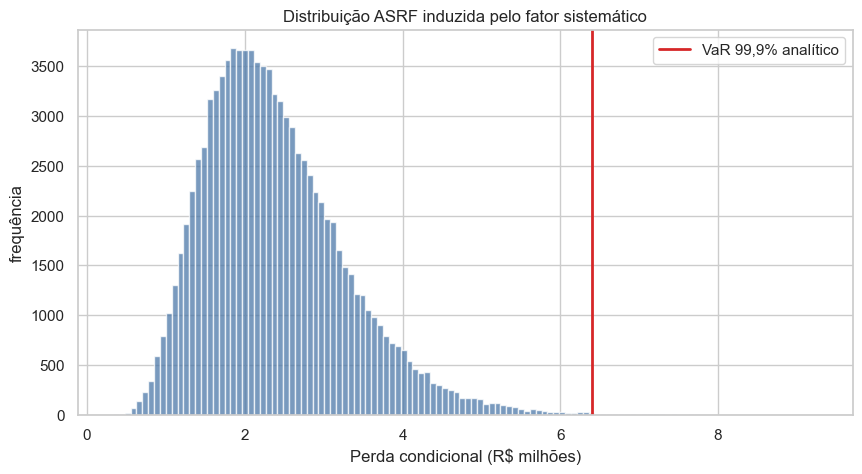

In [19]:
# Monte Carlo vetorizado em blocos para limitar o uso de memória.
rng = np.random.default_rng(20260809)
simulated_w = rng.standard_normal(100_000)
simulated_losses = np.empty_like(simulated_w)
thresholds = ndtri(peak_detail.pd_model.to_numpy())
sqrt_r = np.sqrt(peak_detail.asset_correlation_model.to_numpy())
denominator = np.sqrt(1.0 - peak_detail.asset_correlation_model.to_numpy())
loss_weights = (
    peak_detail.obligor_count.to_numpy()
    * peak_detail.ead_per_obligor.to_numpy()
    * peak_detail.lgd_irb.to_numpy()
)
block = 5_000
for start in range(0, len(simulated_w), block):
    stop = min(start + block, len(simulated_w))
    conditional_pd_matrix = ndtr(
        (thresholds[None, :] - simulated_w[start:stop, None] * sqrt_r[None, :])
        / denominator[None, :]
    )
    simulated_losses[start:stop] = conditional_pd_matrix @ loss_weights

empirical_var = np.quantile(simulated_losses, CONFIDENCE, method='higher')
analytic_var = peak_detail.adverse_loss_pool.sum()
mc_validation = pd.Series({
    'VaR analítico ASRF': analytic_var,
    'VaR empírico (100 mil cenários)': empirical_var,
    'diferença relativa': empirical_var / analytic_var - 1.0,
    'W empírico no quantil inferior': np.quantile(simulated_w, 1.0 - CONFIDENCE),
    'W teórico': ADVERSE_W,
}, name='valor')
display(mc_validation.to_frame())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(simulated_losses / 1e6, bins=120, color='#4c78a8', alpha=0.75)
ax.axvline(analytic_var / 1e6, color='#d62728', linewidth=2,
           label='VaR 99,9% analítico')
ax.set(xlabel='Perda condicional (R$ milhões)', ylabel='frequência',
       title='Distribuição ASRF induzida pelo fator sistemático')
ax.legend()
plt.show()

## 20. Sensibilidade conjunta a PD e LGD

Mantendo $R$ conforme a categoria, o capital marginal por real de EAD é uma função
de PD e LGD. A dependência em LGD é linear para PD e $R$ fixos; a dependência em PD
é não linear. Os mapas calculam a fórmula diretamente, sem interpolar resultados da
carteira.

O painel QRRE mantém $R=4\%$; o painel “demais varejo” recalcula $R(PD)$. Esperamos
faixas horizontais aproximadamente proporcionais à LGD e diferenças importantes
entre categorias em PDs baixas. A figura é útil para revisão de plausibilidade,
não para substituir calibração por uma tabela genérica.

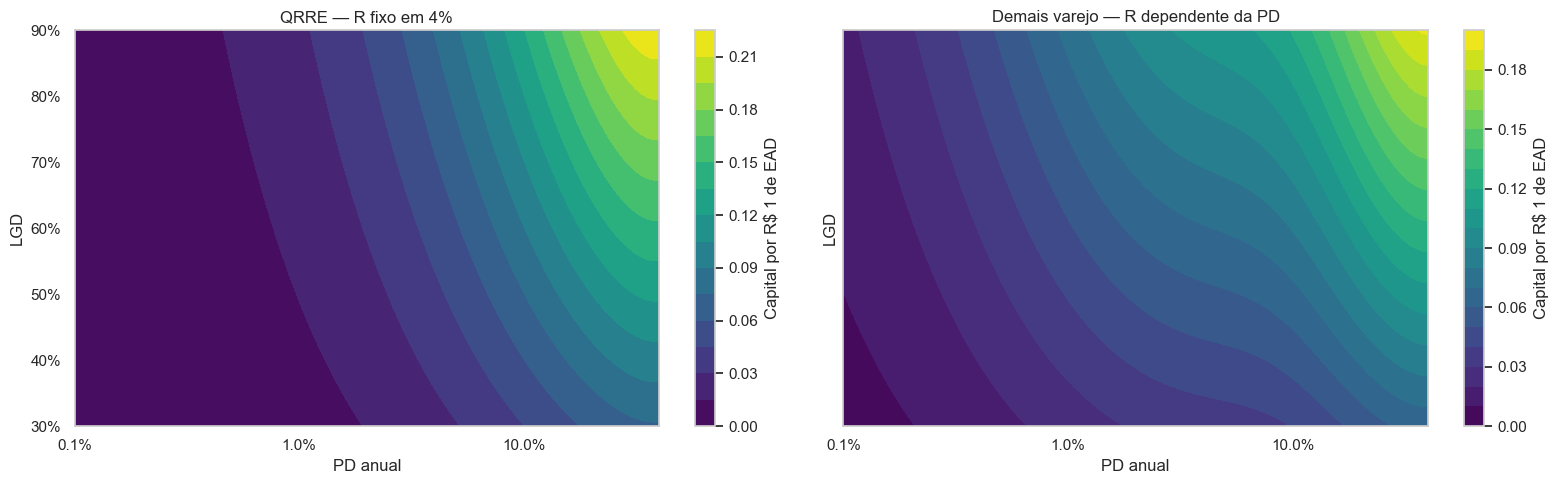

In [20]:
# Superfícies da derivada dCapital/dEAD para as duas subcategorias usadas.
pd_surface = np.geomspace(0.001, 0.40, 100)
lgd_surface = np.linspace(0.30, 0.90, 80)
pd_mesh, lgd_mesh = np.meshgrid(pd_surface, lgd_surface)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)
for ax, category, title in zip(
    axes,
    ['qrre', 'other_retail'],
    ['QRRE — R fixo em 4%', 'Demais varejo — R dependente da PD'],
):
    rho_mesh = retail_asset_correlation(pd_mesh.ravel(), category).reshape(pd_mesh.shape)
    result_mesh = calculate_vasicek_irb(
        pd_mesh.ravel(), np.ones(pd_mesh.size), lgd_mesh.ravel(), rho_mesh.ravel()
    )
    capital_rate_mesh = result_mesh.marginal_capital_per_ead.reshape(pd_mesh.shape)
    contour = ax.contourf(pd_mesh, lgd_mesh, capital_rate_mesh, levels=18, cmap='viridis')
    ax.set_xscale('log')
    ax.set(title=title, xlabel='PD anual', ylabel='LGD')
    ax.xaxis.set_major_formatter(lambda value, _: f'{value:.1%}')
    ax.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
    fig.colorbar(contour, ax=ax, label='Capital por R$ 1 de EAD')
plt.tight_layout()
plt.show()

## 21. Gates finais de integridade e conclusões

Uma execução bem-sucedida não basta; as identidades que definem o estudo precisam
continuar verdadeiras depois de qualquer manutenção. A última célula impõe gates:

1. 24 fechamentos completos e sem valores não finitos;
2. $Capital=L_{99,9\%}-EL$ em todo mês;
3. $RWA=12{,}5\,Capital$;
4. soma contratual igual à soma dos pools;
5. $0\le PD,LGD,K$ e $0\le R<1$;
6. perda condicional decrescente em $W$.

O que o notebook entrega com exatidão é a fórmula ASRF/IRB aplicada aos parâmetros
sintéticos e sua contribuição Euler. O que ele não afirma entregar é uma calibração
regulatória aprovada, capital de concentração, dependência multifatorial, incerteza
de parâmetros ou efeito de migração. Esses itens são extensões metodológicas, não
erros numéricos a serem ocultados dentro da fórmula de Vasicek.

In [21]:
# Asserções finais: falhar cedo é preferível a publicar resultados incoerentes.
monthly_reconciliation = details_over_time.groupby('observation_month').agg(
    EL=('expected_loss_pool', 'sum'),
    Adverse=('adverse_loss_pool', 'sum'),
    Capital=('capital_pool', 'sum'),
    RWA=('rwa_pool', 'sum'),
)
assert len(monthly_reconciliation) == config.reporting_months
assert np.isfinite(monthly_reconciliation.to_numpy()).all()
assert np.allclose(
    monthly_reconciliation.Capital,
    monthly_reconciliation.Adverse - monthly_reconciliation.EL,
)
assert np.allclose(monthly_reconciliation.RWA, 12.5 * monthly_reconciliation.Capital)
assert np.isclose(contracts.capital_contribution.sum(), peak_detail.capital_pool.sum())
assert prepared.pd_irb.between(0.0, 1.0, inclusive='neither').all()
assert prepared.lgd_irb.between(0.0, 1.0, inclusive='both').all()
assert prepared.asset_correlation.between(0.0, 1.0, inclusive='left').all()
assert (details_over_time.marginal_capital_per_ead >= 0.0).all()
assert np.all(np.diff(loss_w) <= 1e-8)

final_summary = pd.DataFrame({
    'gate': ['24 fechamentos', 'Capital = perda adversa − EL',
             'RWA = 12,5 × capital', 'contratos = pools',
             'domínios dos parâmetros', 'L(W) decrescente'],
    'resultado': ['OK'] * 6,
})
display(final_summary)
print('Todos os gates matemáticos e de integridade foram satisfeitos.')

,gate,resultado
0,24 fechamentos,OK
1,Capital = perda adversa − EL,OK
2,"RWA = 12,5 × capital",OK
3,contratos = pools,OK
4,domínios dos parâmetros,OK
5,L(W) decrescente,OK


Todos os gates matemáticos e de integridade foram satisfeitos.
